NAME: MINAL HONALI RAGHUNANDAN

STUDENT ID:6908107

Exploratory data analysis of DEAM dataset

This notebook examines the DEAM corpus before the modelling pipeline is applied. The
annotations analysed here are the raw 1–9 ratings as distributed with the dataset, prior
to normalisation, feature selection, or the train/test split described in Notebook 1.



In [6]:
import matplotlib as mpl

mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "semibold",
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#666666",
    "axes.grid": True,
    "grid.color": "#DDDDDD",
    "grid.linewidth": 0.6,
    "grid.alpha": 0.7,
    "axes.axisbelow": True,
    "legend.frameon": False,
    "xtick.color": "#444444",
    "ytick.color": "#444444",
})

VALENCE_C = "#4C72B0"
AROUSAL_C = "#DD8452"
ACCENT_C  = "#C44E52"

### DATASET OVERVIEW


dataset comprises of DEAM static annotations merged with aggregated openSMILE acoustic feautres, giving 1744 songs in total. Each song carries mean valence and arousal values rating on 1-9 scale and is averaged across multiple human annotations, along with 520 aggregated acoustic descriptors

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/Dissertation/data/processed"
FIG_PATH = "/content/drive/MyDrive/Dissertation/figures"
os.makedirs(FIG_PATH, exist_ok = True)

df = pd.read_csv(os.path.join(DATA_PATH, "deam_full_with_ids.csv"))
song_pool = pd.read_csv(os.path.join(DATA_PATH, "song_pool_predictions.csv"))

print(f"Songs: {len(df)}, columns: {df.shape[1]}")
print(df[["valence_mean", "arousal_mean"]].describe())

Mounted at /content/drive
Songs: 1744, columns: 525
       valence_mean  arousal_mean
count   1744.000000   1744.000000
mean       4.903492      4.812603
std        1.173920      1.289368
min        1.600000      1.600000
25%        4.100000      3.800000
50%        4.900000      4.900000
75%        5.800000      5.800000
max        8.400000      8.100000


## 2. Distribution of Emotion Annotations

Examining the distribution of each target establishes whether the corpus covers the
emotional space evenly or concentrates in particular regions, which directly constrains
what a recommender built on it can retrieve.

Both distributions are approximately symmetric and unimodal, centred close to the scale
midpoint (valence mean 4.90, arousal mean 4.81 on a 1–9 scale). Values toward either
extreme are comparatively infrequent: the interquartile range spans 4.10–5.80 for
valence and 3.80–5.80 for arousal, meaning half of all songs fall within roughly two
points of the midpoint on both dimensions.

This has a practical consequence examined in Chapter 5. A model trained on targets
concentrated near the centre will exhibit regression toward the mean, and recommendations
for extreme mood targets will return the most extreme songs available rather than exact
matches to the requested coordinate.

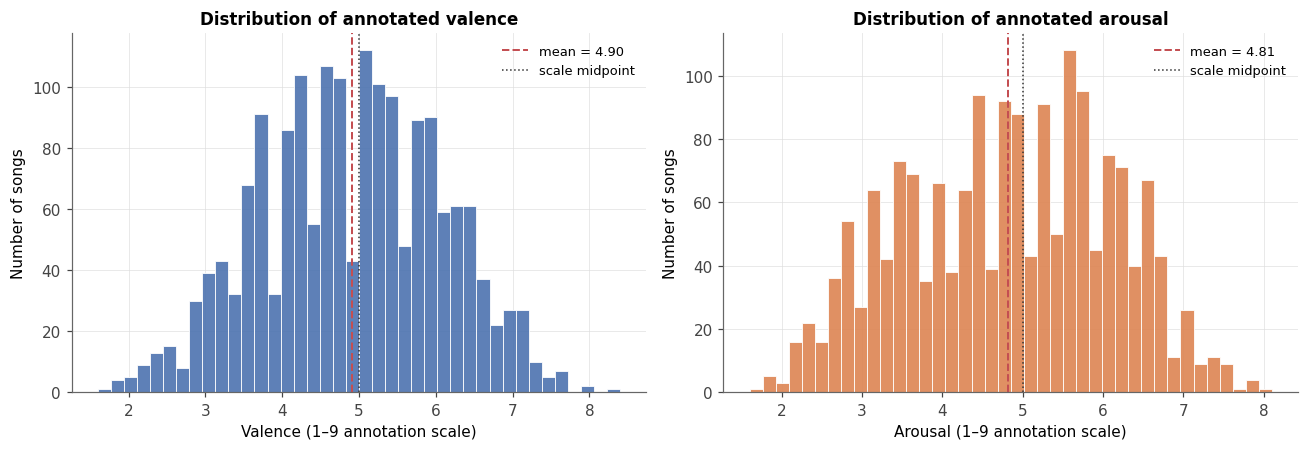

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

for ax, col, label, colour in zip(axes,
                                  ["valence_mean", "arousal_mean"],
                                  ["Valence", "Arousal"],
                                  [VALENCE_C, AROUSAL_C]):
    ax.hist(df[col], bins=40, color=colour, edgecolor="white", linewidth=0.6, alpha=0.9)
    ax.axvline(df[col].mean(), color=ACCENT_C, ls="--", lw=1.3,
               label=f"mean = {df[col].mean():.2f}")
    ax.axvline(5.0, color="#333333", ls=":", lw=1, label="scale midpoint")
    ax.set_xlabel(f"{label} (1–9 annotation scale)")
    ax.set_ylabel("Number of songs")
    ax.set_title(f"Distribution of annotated {label.lower()}")
    ax.legend(fontsize=8.5)

plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, "eda_target_distributions.png"), bbox_inches="tight")
plt.show()

## 3. Joint Distribution and Dimensional Independence

Russell's Circumplex Model treats valence and arousal as orthogonal dimensions, and this
orthogonality is what makes the two-dimensional representation useful: it implies four
genuinely distinct affective quadrants. The assumption is testable directly against the
annotations.

It does not hold in DEAM. The two dimensions correlate at r = 0.588, a moderate positive
relationship visible in the joint distribution as a diagonal concentration running from
low-valence/low-arousal to high-valence/high-arousal. In this corpus, music annotated as
more positive also tends to be annotated as more energetic.

The consequence is uneven coverage of the circumplex, quantified in the following
section. Since a content-based recommender can only retrieve music its catalogue
contains, this bounds the range of moods the system can serve regardless of how accurate
the underlying models are.

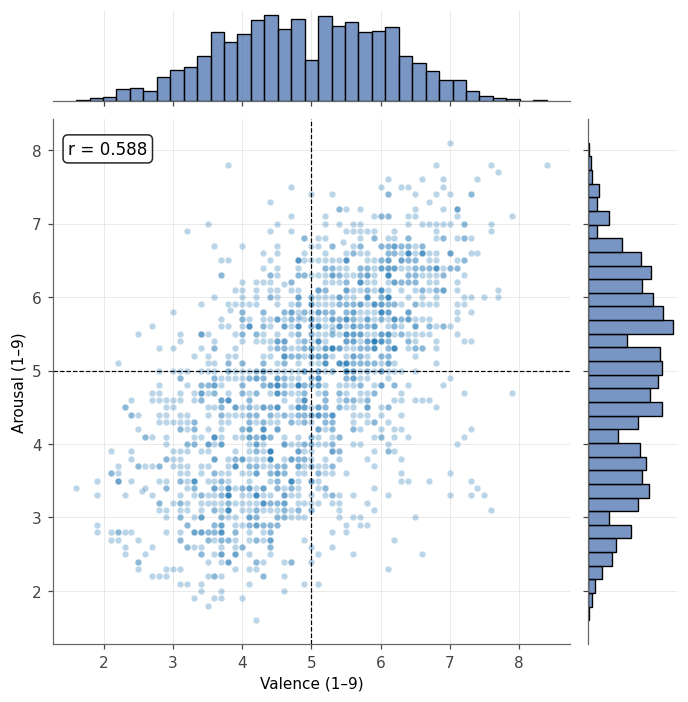

In [10]:
joint_dis = sns.jointplot(data=df, x="valence_mean", y="arousal_mean",
                  kind="scatter", alpha=0.3, s=18, height=6.5,
                  marginal_kws=dict(bins=35, color=VALENCE_C))
joint_dis.ax_joint.axhline(5.0, color="black", ls="--", lw=0.8)
joint_dis.ax_joint.axvline(5.0, color="black", ls="--", lw=0.8)
joint_dis.ax_joint.set_xlabel("Valence (1–9)")
joint_dis.ax_joint.set_ylabel("Arousal (1–9)")

r = df["valence_mean"].corr(df["arousal_mean"])
joint_dis.ax_joint.text(0.03, 0.96, f"r = {r:.3f}", transform=joint_dis.ax_joint.transAxes,
                fontsize=11, va="top",
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))

plt.savefig(os.path.join(FIG_PATH, "eda_joint_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()

## 4. Quadrant Coverage

Assigning songs to circumplex quadrants by thresholding both dimensions at the scale
midpoint gives a concrete measure of catalogue coverage per affective region.

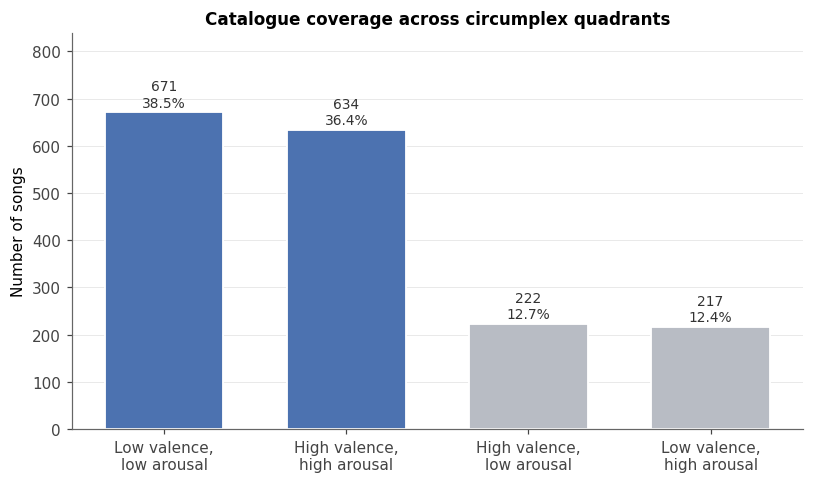

In [8]:
order = ["Low valence,\nlow arousal", "High valence,\nhigh arousal",
         "High valence,\nlow arousal", "Low valence,\nhigh arousal"]
counts = df["quadrant"].value_counts().reindex(order)
colours = ["#4C72B0", "#4C72B0", "#B8BCC4", "#B8BCC4"]

plt.figure(figsize=(7.5, 4.5))
bars = plt.bar(counts.index, counts.values, color=colours,
               edgecolor="white", linewidth=1.2, width=0.65)
for b, v in zip(bars, counts.values):
    plt.text(b.get_x() + b.get_width()/2, v + 12,
             f"{v}\n{v/len(df)*100:.1f}%", ha="center", fontsize=9, color="#333333")

plt.ylabel("Number of songs")
plt.title("Catalogue coverage across circumplex quadrants")
plt.ylim(0, counts.max() * 1.25)
plt.gca().set_axisbelow(True)
plt.grid(axis="x", visible=False)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, "eda_quadrant_balance.png"), bbox_inches="tight")
plt.show()

The imbalance is substantial. The two quadrants aligned with the correlation account for
74.9% of the corpus: low valence with low arousal (671 songs, 38.5%) and high valence
with high arousal (634 songs, 36.4%). The two quadrants running counter to it hold 25.1%
between them: high valence with low arousal (222 songs, 12.7%) and low valence with high
arousal (217 songs, 12.4%).

This is close to a three-to-one imbalance. Calm but positive music, and tense but
negative music, are represented at roughly a third of the density of the two dominant
quadrants. Requests for moods in these regions are therefore served from a smaller pool,
and the retrieved songs sit further from the requested target. This explains the
overlapping recommendations returned for the calm/relaxed and content/serene mood
categories, discussed in Chapter 5.

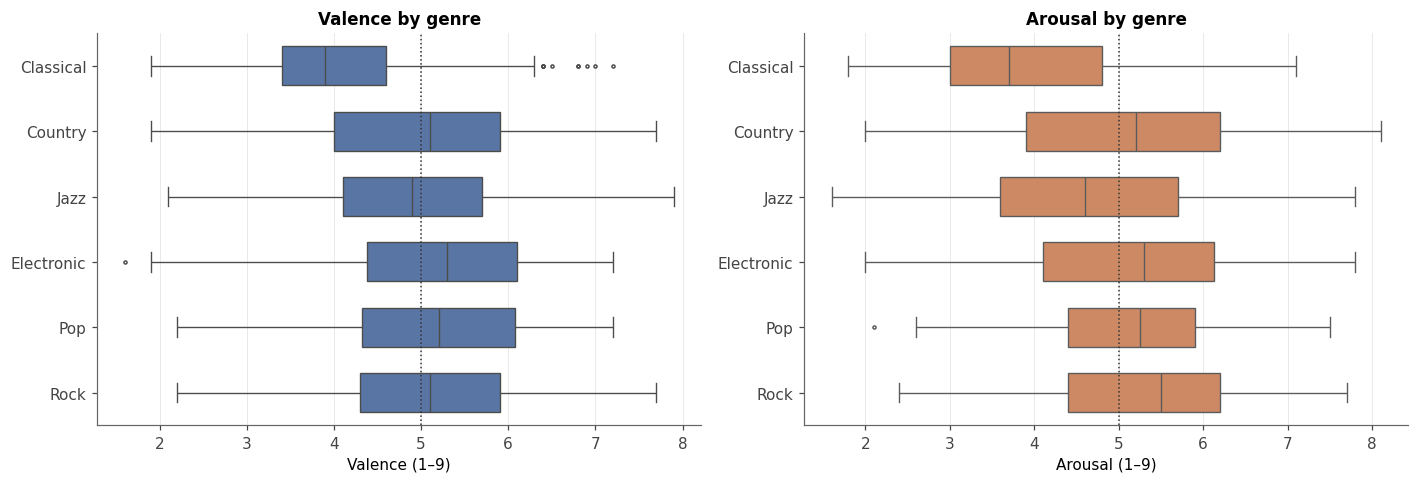

              valence_mean       arousal_mean      
                      mean   std         mean   std
primary_genre                                      
Classical             4.03  1.04         3.91  1.20
Country               5.02  1.25         5.05  1.40
Electronic            5.13  1.20         5.12  1.31
Jazz                  4.90  1.21         4.72  1.31
Pop                   5.11  1.17         5.11  1.13
Rock                  5.10  1.14         5.32  1.17


In [11]:
merged = df.merge(song_pool[["song_id", "Genre"]], on="song_id", how="left")
merged["primary_genre"] = merged["Genre"].astype(str).str.split("-").str[0]

top_genres = merged["primary_genre"].value_counts().head(6).index
subset = merged[merged["primary_genre"].isin(top_genres)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, col, label, colour in zip(axes,
                                  ["valence_mean", "arousal_mean"],
                                  ["Valence", "Arousal"],
                                  [VALENCE_C, AROUSAL_C]):
    sns.boxplot(data=subset, y="primary_genre", x=col, ax=ax,
                order=top_genres, color=colour, width=0.6,
                fliersize=2, linewidth=0.9)
    ax.axvline(5.0, color="#333333", ls=":", lw=1)
    ax.set_xlabel(f"{label} (1–9)")
    ax.set_ylabel("")
    ax.set_title(f"{label} by genre")
    ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, "eda_emotion_by_genre.png"), bbox_inches="tight")
plt.show()

print(subset.groupby("primary_genre")[["valence_mean","arousal_mean"]].agg(["mean","std"]).round(2))

## 5. Data Quality: Imbalance and Outliers

Class imbalance in the conventional sense does not apply here, since both targets are
continuous and the task is regression rather than classification. The relevant form of
imbalance is the uneven quadrant coverage documented above, which is a property of the
corpus rather than something correctable by resampling: synthesising songs in the sparse
regions is not meaningful, and discarding songs from the dense regions would further
reduce an already small dataset.

On outliers, both annotation distributions are unimodal with no isolated extreme values.
Valence ranges from 1.60 to 8.40 and arousal from 1.60 to 8.10. Values at the extremes
represent genuinely extreme music rather than annotation errors, and were retained.

At the feature level, missing values were imputed with the column median and zero-variance
features removed, as described in Notebook 1. Feature-level outliers were not removed:
gradient-boosted trees are insensitive to monotone transformations of individual features
and are therefore robust to extreme values in a way that linear models are not.

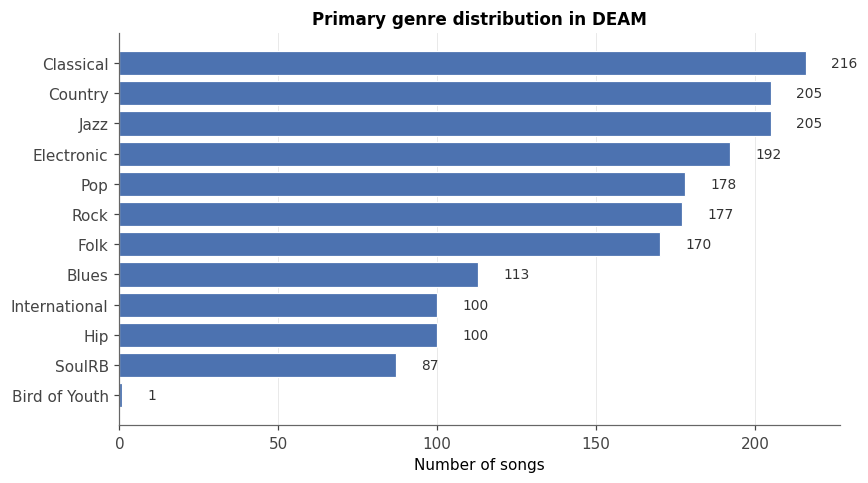

Distinct genre labels: 31
Genre
Classical        216
Country          205
Jazz             205
Electronic       192
Pop              178
Rock             177
Folk             170
Blues            113
International    100
Hip              100
SoulRB            87
Bird of Youth      1
Name: count, dtype: int64


In [12]:
genre_counts = song_pool["Genre"].value_counts()
primary = song_pool["Genre"].astype(str).str.split("-").str[0].value_counts().head(12)

plt.figure(figsize=(8, 4.5))
bars = plt.barh(primary.index[::-1], primary.values[::-1],
                color=VALENCE_C, edgecolor="white", linewidth=0.8)
for b, v in zip(bars, primary.values[::-1]):
    plt.text(v + 8, b.get_y() + b.get_height()/2, str(v),
             va="center", fontsize=9, color="#333333")
plt.xlabel("Number of songs")
plt.title("Primary genre distribution in DEAM")
plt.grid(axis="y", visible=False)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, "eda_genre_distribution.png"), bbox_inches="tight")
plt.show()

print(f"Distinct genre labels: {genre_counts.nunique()}")
print(primary)